# AVOCADO 가격 예측 (Facebook Prophet )



# STEP #0: 데이터셋

- 데이터는 미국의 아보카도 리테일 데이터 입니다. (2018년도 weekly 데이터)  
- 아보카도 거래량과 가격이 나와 있습니다.

컬럼 설명 :

- Date - 날짜
- AveragePrice - 아보카도 가격
- type - conventional or organic (전통방식이냐, 유기농이냐)
- year - 판매년도
- Region - 판매지역
- Total Volume - 아보카도 판매수량
- 4046 - 농산물 코드입니다
- 4225 - 농산물 코드입니다
- 4770 - 농산물 코드입니다



# STEP #1: 데이터 준비

### Prophet 라이브러리


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [347]:
# avocado.csv 데이터 읽기

df_avocado =pd.read_csv('../data/avocado.csv', index_col= 0 ,parse_dates= ['Date'])

# STEP #2: EDA(Exploratory Data Analysis) :  탐색적 데이터 분석

In [247]:
df_avocado.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [174]:
df_avocado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18249 entries, 0 to 11
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          18249 non-null  datetime64[ns]
 1   AveragePrice  18249 non-null  float64       
 2   Total Volume  18249 non-null  float64       
 3   4046          18249 non-null  float64       
 4   4225          18249 non-null  float64       
 5   4770          18249 non-null  float64       
 6   Total Bags    18249 non-null  float64       
 7   Small Bags    18249 non-null  float64       
 8   Large Bags    18249 non-null  float64       
 9   XLarge Bags   18249 non-null  float64       
 10  type          18249 non-null  object        
 11  year          18249 non-null  int64         
 12  region        18249 non-null  object        
dtypes: datetime64[ns](1), float64(9), int64(1), object(2)
memory usage: 1.9+ MB


### 데이터의 날짜가 뒤죽박죽 입니다. 날짜로 정렬하시오.

In [248]:
df_avocado.sort_values('Date', inplace=True)

In [249]:
df_avocado.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
51,2015-01-04,1.75,27365.89,9307.34,3844.81,615.28,13598.46,13061.10,537.36,0.0,organic,2015,Southeast
51,2015-01-04,1.49,17723.17,1189.35,15628.27,0.00,905.55,905.55,0.00,0.0,organic,2015,Chicago
51,2015-01-04,1.68,2896.72,161.68,206.96,0.00,2528.08,2528.08,0.00,0.0,organic,2015,HarrisburgScranton
51,2015-01-04,1.52,54956.80,3013.04,35456.88,1561.70,14925.18,11264.80,3660.38,0.0,conventional,2015,Pittsburgh
51,2015-01-04,1.64,1505.12,1.27,1129.50,0.00,374.35,186.67,187.68,0.0,organic,2015,Boise


### 날짜별로 가격이 어떻게 변하는지 간단하게 확인하시오. (plot 이용)

In [250]:
df_avocado['Date'].unique()

<DatetimeArray>
['2015-01-04 00:00:00', '2015-01-11 00:00:00', '2015-01-18 00:00:00',
 '2015-01-25 00:00:00', '2015-02-01 00:00:00', '2015-02-08 00:00:00',
 '2015-02-15 00:00:00', '2015-02-22 00:00:00', '2015-03-01 00:00:00',
 '2015-03-08 00:00:00',
 ...
 '2018-01-21 00:00:00', '2018-01-28 00:00:00', '2018-02-04 00:00:00',
 '2018-02-11 00:00:00', '2018-02-18 00:00:00', '2018-02-25 00:00:00',
 '2018-03-04 00:00:00', '2018-03-11 00:00:00', '2018-03-18 00:00:00',
 '2018-03-25 00:00:00']
Length: 169, dtype: datetime64[ns]

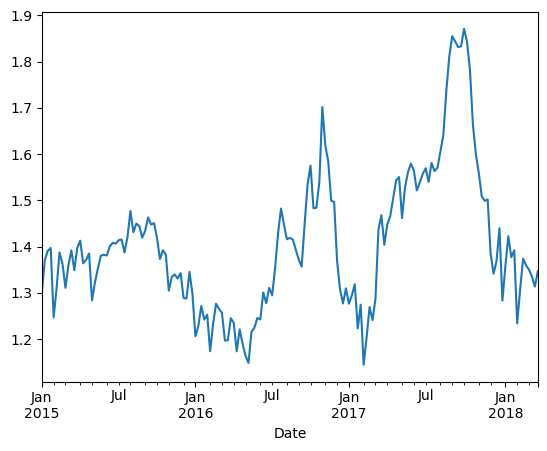

In [251]:
# 날짜별 가격의 평균값을 구한 뒤 차트로 시각화
df_avocado.groupby('Date')['AveragePrice'].mean().plot()
plt.show()

### 'region' 별로 데이터 몇개인지 시각화 하시오.

In [252]:
df_avocado['region'].unique()

array(['Southeast', 'Chicago', 'HarrisburgScranton', 'Pittsburgh',
       'Boise', 'WestTexNewMexico', 'LosAngeles', 'LasVegas', 'Atlanta',
       'DallasFtWorth', 'MiamiFtLauderdale', 'Plains', 'StLouis',
       'Syracuse', 'Midsouth', 'Sacramento', 'Boston', 'Charlotte',
       'Spokane', 'Albany', 'Houston', 'SouthCarolina', 'SanFrancisco',
       'TotalUS', 'RaleighGreensboro', 'BuffaloRochester',
       'NorthernNewEngland', 'GrandRapids', 'Denver', 'SanDiego',
       'BaltimoreWashington', 'Roanoke', 'RichmondNorfolk', 'Northeast',
       'SouthCentral', 'GreatLakes', 'Louisville', 'Seattle',
       'CincinnatiDayton', 'NewYork', 'NewOrleansMobile', 'Indianapolis',
       'Jacksonville', 'Columbus', 'Detroit', 'Philadelphia',
       'PhoenixTucson', 'Nashville', 'Portland', 'HartfordSpringfield',
       'Tampa', 'Orlando', 'West', 'California'], dtype=object)

In [253]:
df_avocado['region'].nunique()

54

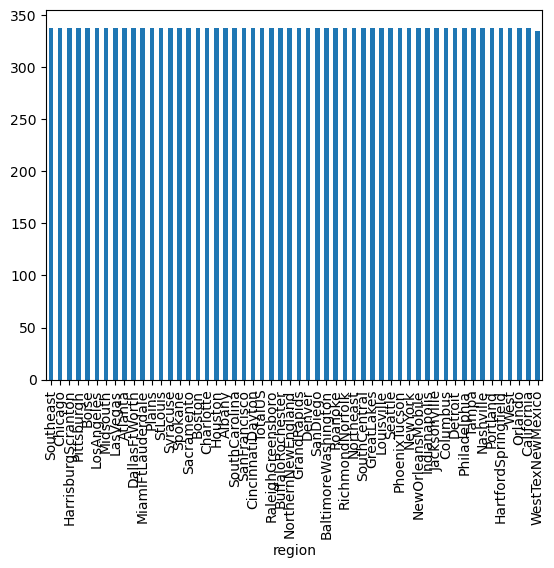

In [254]:
df_avocado['region'].value_counts().plot(kind = 'bar')
plt.show()

### 년도('year')별로 데이터가 몇건인지 확인하시오.

In [255]:
df_avocado['year']

51    2015
51    2015
51    2015
51    2015
51    2015
      ... 
0     2018
0     2018
0     2018
0     2018
0     2018
Name: year, Length: 18249, dtype: int64

In [188]:
df_avocado['year'].unique()

array([2015, 2016, 2017, 2018])

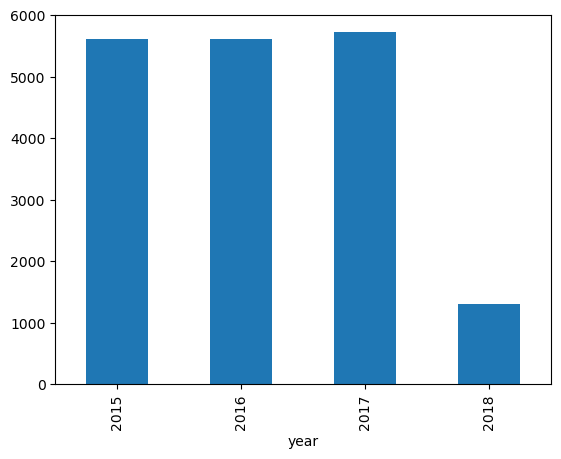

In [256]:
df_avocado['year'].value_counts().sort_index().plot(kind = 'bar')
plt.show()

In [257]:
df_avocado['Date'].unique()

<DatetimeArray>
['2015-01-04 00:00:00', '2015-01-11 00:00:00', '2015-01-18 00:00:00',
 '2015-01-25 00:00:00', '2015-02-01 00:00:00', '2015-02-08 00:00:00',
 '2015-02-15 00:00:00', '2015-02-22 00:00:00', '2015-03-01 00:00:00',
 '2015-03-08 00:00:00',
 ...
 '2018-01-21 00:00:00', '2018-01-28 00:00:00', '2018-02-04 00:00:00',
 '2018-02-11 00:00:00', '2018-02-18 00:00:00', '2018-02-25 00:00:00',
 '2018-03-04 00:00:00', '2018-03-11 00:00:00', '2018-03-18 00:00:00',
 '2018-03-25 00:00:00']
Length: 169, dtype: datetime64[ns]

In [258]:
# 요일정보 확인해보기(확인용이니 문자로 나오게 day_name 사용)
df_avocado['Date'].dt.day_name()

51    Sunday
51    Sunday
51    Sunday
51    Sunday
51    Sunday
       ...  
0     Sunday
0     Sunday
0     Sunday
0     Sunday
0     Sunday
Name: Date, Length: 18249, dtype: object

### 프로펫 분석을 위해, 두개의 컬럼만 가져오시오. ('Date', 'AveragePrice')

In [353]:
# df = df_avocado.loc[ : ,'Date': 'AveragePrice']
df = df_avocado[ ['Date','AveragePrice'] ]

In [354]:
df.head()

,Date,AveragePrice
0,2015-12-27,1.33
1,2015-12-20,1.35
2,2015-12-13,0.93
3,2015-12-06,1.08
4,2015-11-29,1.28


In [349]:
df = df.groupby('Date')['AveragePrice'].mean().to_frame()

In [337]:
df.reset_index()

,Date,AveragePrice
0,2015-01-04,1.301296
1,2015-01-11,1.370648
2,2015-01-18,1.391111
3,2015-01-25,1.397130
4,2015-02-01,1.247037
...,...,...
164,2018-02-25,1.359630
165,2018-03-04,1.350185
166,2018-03-11,1.335093
167,2018-03-18,1.313704


# STEP 3: Prophet 을 이용한 예측 수행

### ds 와 y 로 컬럼명을 셋팅하시오.

In [338]:
from prophet import Prophet

In [339]:
# 시계열 예측, 분석 (=timeseries)
model = Prophet()

In [355]:
# 1번
df = df.rename(columns= {'Date' : 'ds', 'AveragePrice' : 'y'})

In [320]:
# 2번
# df.columns = ['ds' , 'y' ]

In [356]:
df

,ds,y
0,2015-12-27,1.33
1,2015-12-20,1.35
2,2015-12-13,0.93
3,2015-12-06,1.08
4,2015-11-29,1.28
...,...,...
7,2018-02-04,1.63
8,2018-01-28,1.71
9,2018-01-21,1.87
10,2018-01-14,1.93


### 프로펫 예측 하시오.

In [357]:
model.fit(df)

15:11:32 - cmdstanpy - INFO - Chain [1] start processing
15:11:36 - cmdstanpy - INFO - Chain [1] done processing


In [358]:
# 365일치를 예측하시오.
future = model.make_future_dataframe( periods = 40, freq = 'W' )

In [359]:
forecast = model.predict(future)

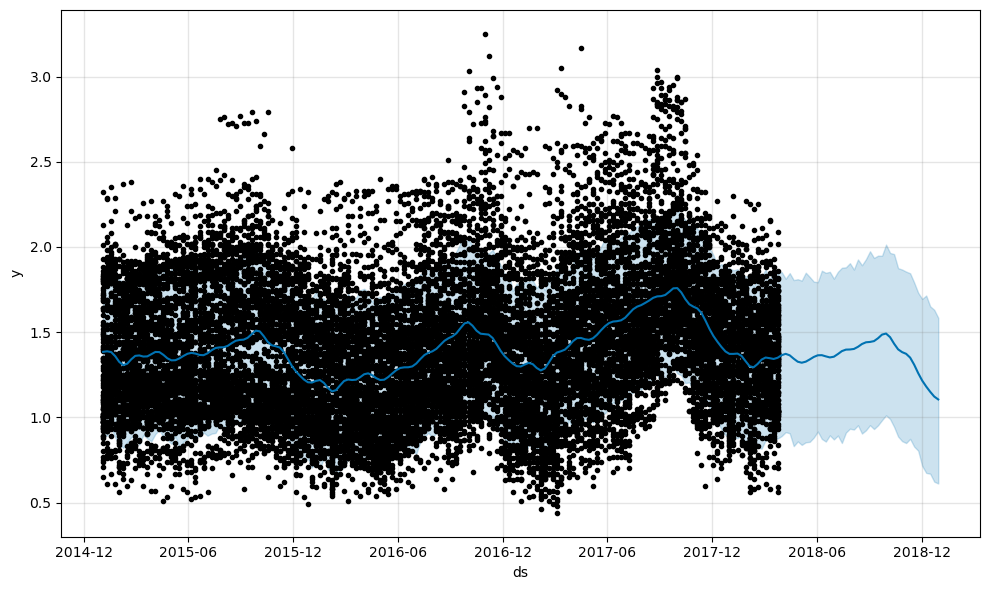

In [360]:
# 차트로 확인하시오.
model.plot(forecast)
plt.show()

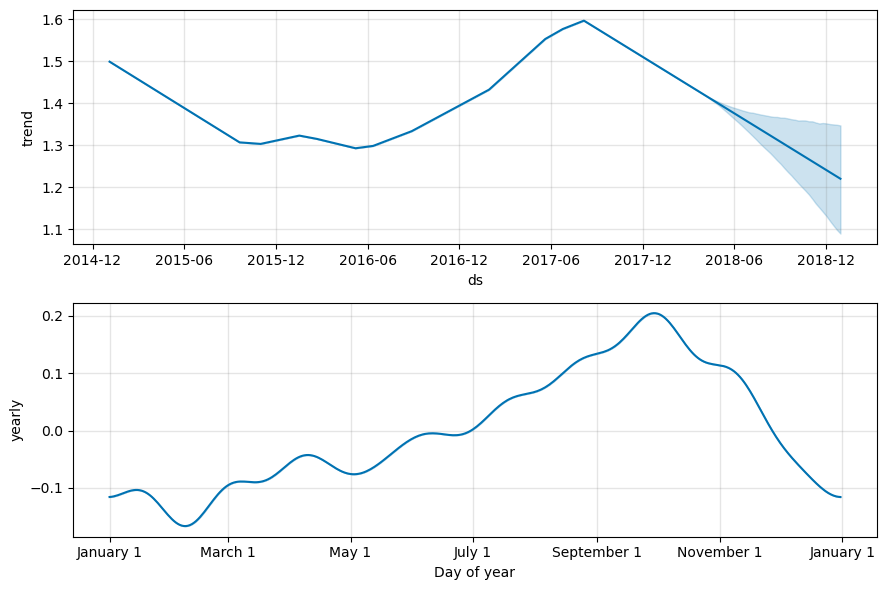

In [361]:
model.plot_components(forecast)
plt.show()

# PART 2 : region 이 west 인 아보카도의 가격을 예측하시오.

In [295]:
df_avocado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18249 entries, 0 to 11
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          18249 non-null  datetime64[ns]
 1   AveragePrice  18249 non-null  float64       
 2   Total Volume  18249 non-null  float64       
 3   4046          18249 non-null  float64       
 4   4225          18249 non-null  float64       
 5   4770          18249 non-null  float64       
 6   Total Bags    18249 non-null  float64       
 7   Small Bags    18249 non-null  float64       
 8   Large Bags    18249 non-null  float64       
 9   XLarge Bags   18249 non-null  float64       
 10  type          18249 non-null  object        
 11  year          18249 non-null  int64         
 12  region        18249 non-null  object        
dtypes: datetime64[ns](1), float64(9), int64(1), object(2)
memory usage: 1.9+ MB


In [267]:
df =pd.read_csv('../data/avocado.csv', index_col= 0 ,parse_dates= ['Date'])

In [297]:
# 1번 west찾기 
sorted(df_avocado['region'].unique())

['Albany',
 'Atlanta',
 'BaltimoreWashington',
 'Boise',
 'Boston',
 'BuffaloRochester',
 'California',
 'Charlotte',
 'Chicago',
 'CincinnatiDayton',
 'Columbus',
 'DallasFtWorth',
 'Denver',
 'Detroit',
 'GrandRapids',
 'GreatLakes',
 'HarrisburgScranton',
 'HartfordSpringfield',
 'Houston',
 'Indianapolis',
 'Jacksonville',
 'LasVegas',
 'LosAngeles',
 'Louisville',
 'MiamiFtLauderdale',
 'Midsouth',
 'Nashville',
 'NewOrleansMobile',
 'NewYork',
 'Northeast',
 'NorthernNewEngland',
 'Orlando',
 'Philadelphia',
 'PhoenixTucson',
 'Pittsburgh',
 'Plains',
 'Portland',
 'RaleighGreensboro',
 'RichmondNorfolk',
 'Roanoke',
 'Sacramento',
 'SanDiego',
 'SanFrancisco',
 'Seattle',
 'SouthCarolina',
 'SouthCentral',
 'Southeast',
 'Spokane',
 'StLouis',
 'Syracuse',
 'Tampa',
 'TotalUS',
 'West',
 'WestTexNewMexico']

In [300]:
# 2번 west찾기 
df_avocado.loc[df_avocado['region'].str.lower().str.contains('west'),].head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,0.83,5291979.63,2038443.68,1717599.45,125254.82,1410681.68,838267.79,567269.76,5144.13,conventional,2015,West
1,2015-12-20,0.88,4737649.03,2017331.24,1314711.00,130849.60,1274757.19,843691.13,417746.45,13319.61,conventional,2015,West
2,2015-12-13,0.85,4899439.92,1798995.46,1596329.01,134101.62,1370013.83,851506.76,517936.19,570.88,conventional,2015,West
3,2015-12-06,0.75,6202513.84,2097720.52,2051392.83,107568.34,1945832.15,1360760.83,582846.33,2224.99,conventional,2015,West
4,2015-11-29,0.99,3719603.21,1461861.54,1216811.00,104219.76,936710.91,688674.00,247318.15,718.76,conventional,2015,West


In [302]:
df_west = df[df['region'] == 'West']

In [269]:
# 1. ds, y 컬럼 변경하기 
avocado_df_sample = df_west[['Date', 'AveragePrice']].rename(columns={'Date': 'ds', 'AveragePrice': 'y'})

In [ ]:
# 2. ds, y 컬럼 변경하기 
df_west.rename(columns= {'Date' : 'ds' , 'AveragePrice': 'y'}, inplace=True)

In [270]:
avocado_df_sample

,ds,y
0,2015-12-27,0.83
1,2015-12-20,0.88
2,2015-12-13,0.85
3,2015-12-06,0.75
4,2015-11-29,0.99
...,...,...
7,2018-02-04,1.41
8,2018-01-28,1.80
9,2018-01-21,1.83
10,2018-01-14,1.82


In [303]:
model = Prophet()

In [304]:
model.fit(avocado_df_sample)

15:02:53 - cmdstanpy - INFO - Chain [1] start processing
15:02:53 - cmdstanpy - INFO - Chain [1] done processing


In [305]:
future = model.make_future_dataframe(periods=40, freq='W')

In [306]:
forecast = model.predict(future)

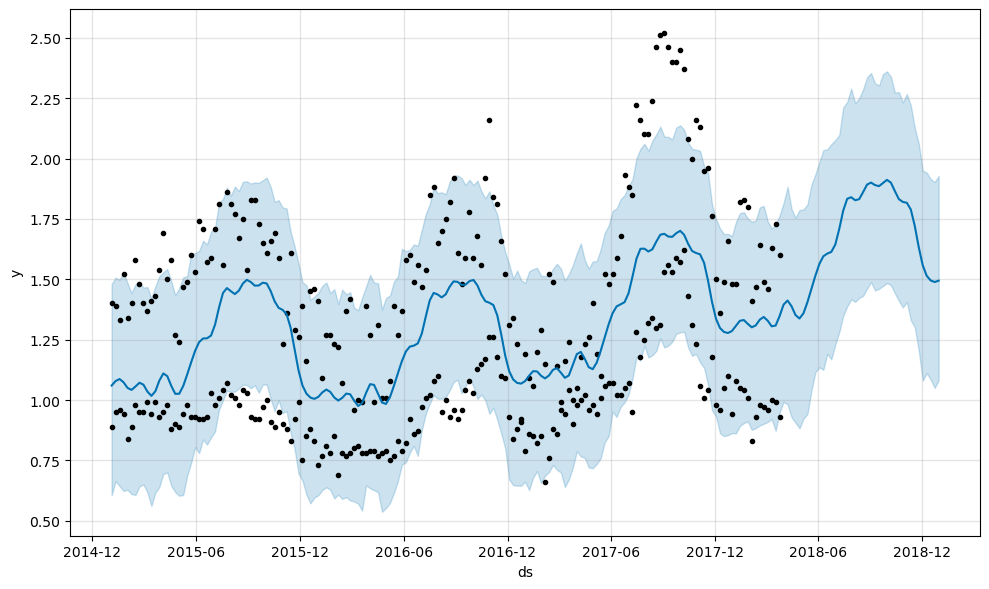

In [307]:
model.plot(forecast)
plt.show()

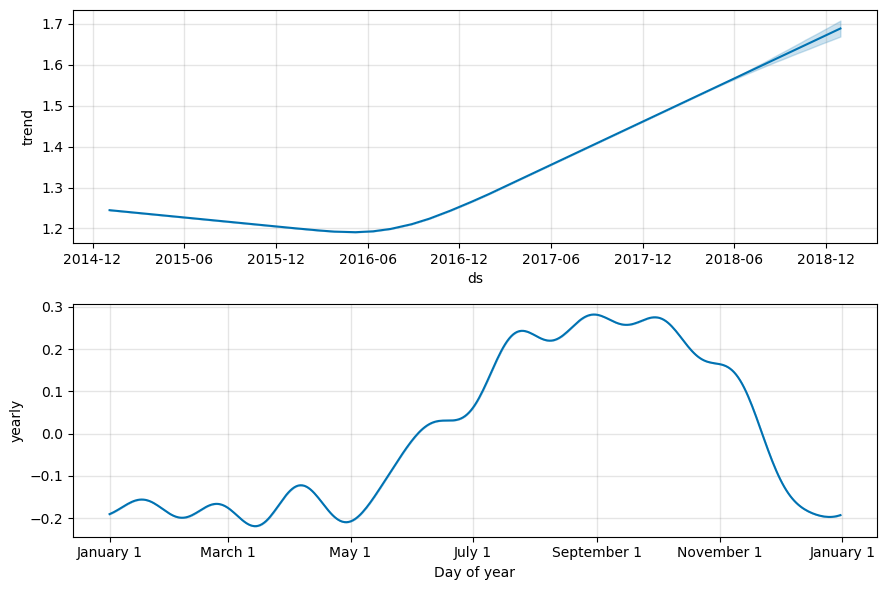

In [308]:
model.plot_components(forecast)
plt.show()